In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

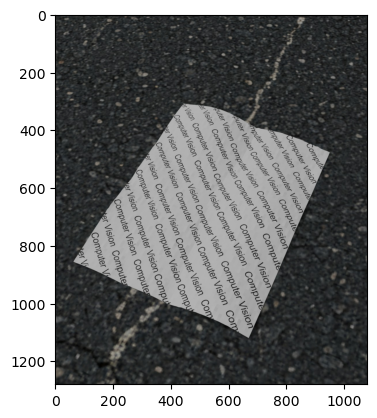

In [344]:
image = cv2.imread("synthetic_data/input (70).jpg")
# show color image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

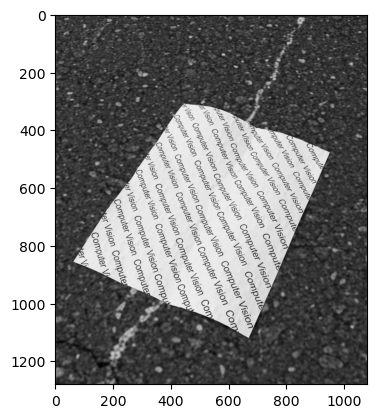

In [345]:
imGray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(imGray, cmap='gray')

In [346]:
img_scale = 0.25
small = cv2.resize(imGray, None, fx=img_scale, fy=img_scale)
small_color = cv2.resize(image, None, fx=img_scale, fy=img_scale)
blurred_small = cv2.bilateralFilter(small, 9, 75, 75)

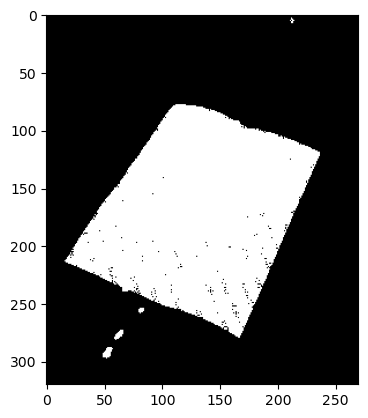

In [347]:
otsuVal, otsuThresh = cv2.threshold(blurred_small, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(otsuThresh, cmap='gray')

In [348]:
kernel = np.ones((3,3), np.uint8)
# kernel = np.ones((5,5), np.uint8)
cleaned = cv2.morphologyEx(otsuThresh, cv2.MORPH_OPEN, kernel)


# kernel_close = np.ones((7,7), np.uint8)
# kernel_open = np.ones((5,5), np.uint8)
# cleaned = cv2.morphologyEx(otsuThresh, cv2.MORPH_CLOSE, kernel_close)  # bridge gaps first
# cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel_open)        # then kill noise
contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
maxContour = max(contours, key=cv2.contourArea)

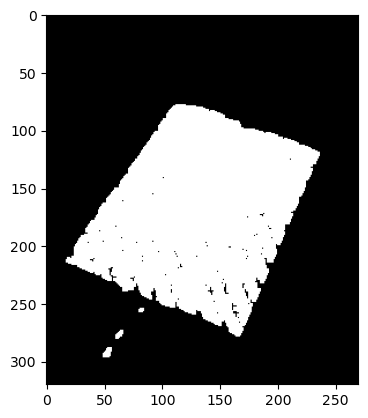

In [349]:
plt.imshow(cleaned, cmap='gray')

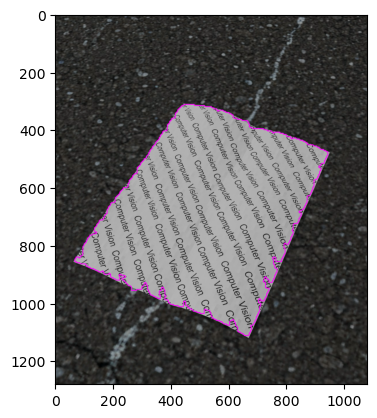

In [350]:
output = image.copy()
cv2.drawContours(output, [(maxContour / img_scale).astype(np.int32)], -1, (255, 0, 255), 2)
plt.imshow(output)

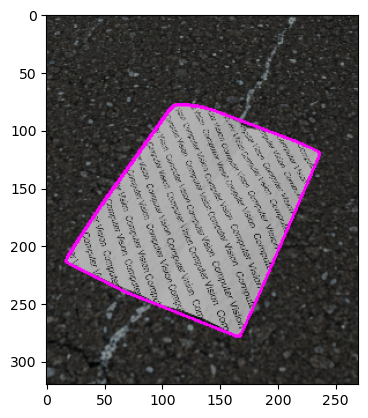

In [351]:
hull = cv2.convexHull(maxContour)
plt.imshow(cv2.drawContours(small_color.copy(), [hull], -1, (255, 0, 255), 2))

Found 4 corners with scale 0.02
[[[112  78]]

 [[236 119]]

 [[167 278]]

 [[ 17 214]]]


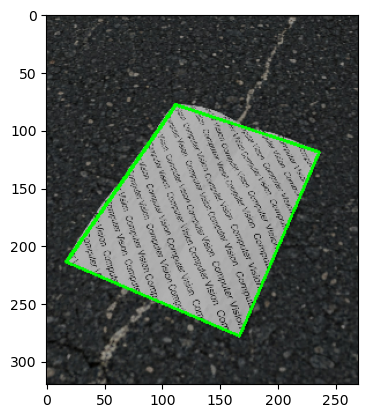

In [352]:
for scale in [0.02, 0.03, 0.04, 0.05, 0.06, 0.1]:
    epsilon = scale * cv2.arcLength(hull, True)
    approx = cv2.approxPolyDP(hull, epsilon, True)
    if len(approx) == 4:
        print(f"Found 4 corners with scale {scale}")
        break

output = small_color.copy()
cv2.drawContours(output, [approx], -1, (0, 255, 0), 2)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
print(approx)

In [353]:
# contour_pts = maxContour.reshape(-1, 2)
contour_pts = approx.reshape(-1, 2)
sums = contour_pts.sum(axis=1)
diffs = np.diff(contour_pts, axis=1).flatten()

tl = contour_pts[np.argmin(sums)]
br = contour_pts[np.argmax(sums)]
tr = contour_pts[np.argmin(diffs)]
bl = contour_pts[np.argmax(diffs)]

ordered_approx = np.array([tl, tr, br, bl])
print(ordered_approx)

[[112  78]
 [236 119]
 [167 278]
 [ 17 214]]


In [354]:
approx_full = (ordered_approx / img_scale).astype(np.int32)

In [355]:
approx_full

array([[ 448,  312],
       [ 944,  476],
       [ 668, 1112],
       [  68,  856]], dtype=int32)

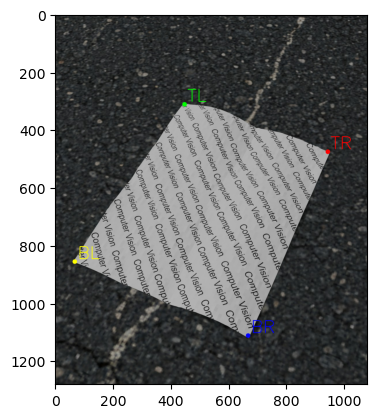

In [356]:
output = image.copy()
colors = [(0,255,0), (0,0,255), (255,0,0), (0,255,255)]  # TL, TR, BR, BL
labels = ['TL', 'TR', 'BR', 'BL']

for i, (x, y) in enumerate(approx_full):
    cv2.circle(output, (x, y), 8, colors[i], -1)           # draw colored circle
    cv2.putText(output, labels[i], (x+10, y-10),           # add label
                cv2.FONT_HERSHEY_SIMPLEX, 2.0, colors[i], 2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))